# Multi-Modal Predicates

All previous notebooks bind a single tensor to each logical variable. pysignet also
accepts a **dict** as the value of a variable, which lets different predicates read
different slices of the same sample. This is the natural representation when one logical
sample carries heterogeneous inputs.

This notebook demonstrates the pattern with a fully synthetic two-view dataset. Each
sample belongs to one of two classes and is observed through two independent noisy
sensors, producing two feature vectors:

```python
x = {"view_a": sensor_a_reading, "view_b": sensor_b_reading}
```

We train one classifier per sensor and enforce that they agree:

$$\forall X:\; \text{ViewA}(X) \leftrightarrow \text{ViewB}(X)$$

On labeled data both classifiers are supervised directly. On unlabeled data neither
label is known, but the constraint still applies: whenever one classifier is confident,
it acts as a teacher for the other. This is the co-training idea, implemented as a
pysignet consistency loss.

By the end of this notebook, we will have seen:

1. How to bind a dict to a variable so each predicate reads its own slice
2. How cross-view consistency acts as a semi-supervised signal
3. How the dict pattern relates to the single-tensor and multi-variable patterns
   used in earlier notebooks


## Preliminaries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import pysignet as psn

## The logic

In [2]:
ViewA = psn.Symbol("ViewA")
ViewB = psn.Symbol("ViewB")
X     = psn.Variable("X")
Y     = psn.Variable("Y")  # class label (0 or 1)

supervised_a    = ViewA(X, Y)                              # class-selector pattern
supervised_b    = ViewB(X, Y)
constraint_expr = psn.ForAll(Y, [0, 1] ,psn.Equivalent(ViewA(X, Y), ViewB(X, Y)) ) # agree on class 1

print("Supervised (A):       ", supervised_a)
print("Supervised (B):       ", supervised_b)
print("Cross-view constraint:", constraint_expr)

Supervised (A):        ViewA(X, Y)
Supervised (B):        ViewB(X, Y)
Cross-view constraint: ForAll(Y, [0, 1], Equivalent(ViewB(X, Y), ViewA(X, Y)))


## The data

Each sample belongs to class 0 or class 1. The class signal is a scalar of +1 (class 0)
or -1 (class 1). Each sensor adds independent Gaussian noise (standard deviation 2.5),
producing an 8-dimensional reading per view. With this noise level each view alone is
unreliable, making the semi-supervised signal from the constraint more valuable.

We use 20 labeled samples and 5,000 unlabeled samples.

In [3]:
VIEW_DIM    = 8
NOISE_STD   = 2.5
N_LABELED   = 20
N_UNLABELED = 5_000
N_TEST      = 2_000


def make_data(
    n: int, noise_std: float = NOISE_STD, seed: int = 0
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Return (view_a, view_b, labels) with balanced classes."""
    torch.manual_seed(seed)
    labels = torch.randint(0, 2, (n,))
    signal = (2 * labels.float() - 1).unsqueeze(1)        # ±1, shape (n, 1)
    view_a = signal.expand(-1, VIEW_DIM) + torch.randn(n, VIEW_DIM) * noise_std
    view_b = signal.expand(-1, VIEW_DIM) + torch.randn(n, VIEW_DIM) * noise_std
    return view_a, view_b, labels.float()


va_l, vb_l, y_l = make_data(N_LABELED,    seed=1)
va_u, vb_u, _   = make_data(N_UNLABELED,  seed=2)
va_t, vb_t, y_t = make_data(N_TEST,       seed=3)

# Give labeled_loader its own generator so its shuffle order is independent
# of how many random numbers the unlabeled_loader consumes each epoch.
labeled_loader   = DataLoader(
    TensorDataset(va_l, vb_l, y_l),
    batch_size=16,
    shuffle=True,
    generator=torch.Generator().manual_seed(0),
)
unlabeled_loader = DataLoader(TensorDataset(va_u, vb_u),       batch_size=128, shuffle=True)
test_loader      = DataLoader(TensorDataset(va_t, vb_t, y_t),  batch_size=256, shuffle=False)

print(f"Labeled:   {N_LABELED}  (class balance: {y_l.mean():.2f})")
print(f"Unlabeled: {N_UNLABELED}")
print(f"Test:      {N_TEST}")

Labeled:   20  (class balance: 0.55)
Unlabeled: 5000
Test:      2000


## The models and evaluator

Each sensor gets its own small MLP. The `evaluate` function measures accuracy of the
view-A classifier using the `Label(Y)` equivalence pattern from the
[Triplet Learning notebook](Triplet%20Learning.ipynb).

In [4]:
class ViewModel(nn.Module):
    def __init__(self, input_dim: int = VIEW_DIM) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 2),   # 2-class logits; pysignet applies softmax and selects class Y
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def evaluate(
    model_a: nn.Module, model_b: nn.Module, loader: DataLoader
) -> tuple[float, float]:
    """Accuracy of ViewA and ViewB classifiers separately."""
    checker_a = psn.consistency_report(supervised_a, {"ViewA": model_a})
    checker_b = psn.consistency_report(supervised_b, {"ViewB": model_b})
    for va, vb, y in loader:
        checker_a.eval(X=va, Y=y.long())
        checker_b.eval(X=vb, Y=y.long())
    return checker_a.global_consistency(), checker_b.global_consistency()

## The dict-as-variable pattern

The only new syntax in this notebook is binding a dict to `X`:

```python
predicates = {
    "ViewA": lambda x, c: F.softmax(model_a(x["view_a"]), dim=-1)[:, int(c)],
    "ViewB": lambda x, c: F.softmax(model_b(x["view_b"]), dim=-1)[:, int(c)],
}
constraint = psn.logic_to_loss(constraint_expr, predicates)

x = {"view_a": va_batch, "view_b": vb_batch}
loss = constraint.loss(X=x, quantify="none", reduction="mean")
```

`ViewA` never sees `view_b` and `ViewB` never sees `view_a`.

The supervised expressions use the same class-selector pattern as the
[MNIST notebook](MNIST.ipynb): `ViewA(X, Y)` passes `X` to the model and selects the
output at index `Y`. When registered as an `nn.Module`, pysignet applies softmax
internally and picks the class-`Y` probability. The loss `1 - p_Y` is minimised when
the model is confident about the correct class, which is equivalent to cross-entropy.

Contrast with the two other binding patterns from earlier notebooks:

```python
# Single tensor -- one object, one input (MNIST, Semi-Supervised MNIST, ...):
loss = compiled.loss(X=image_tensor)

# Multiple variables -- two separate objects (Symmetry, Triplet Learning):
loss = compiled.loss(X1=tensor_a, X2=tensor_b)

# Dict -- one object, multiple heterogeneous inputs (this notebook):
loss = compiled.loss(X={"view_a": tensor_a, "view_b": tensor_b})
```

## Training

In [5]:
def train_supervised(
    n_epochs: int = 15, lr: float = 1e-3
) -> tuple[nn.Module, list[float], list[float]]:
    model_a = ViewModel()
    model_b = ViewModel()

    sup_a = psn.logic_to_loss(supervised_a, {"ViewA": model_a})
    sup_b = psn.logic_to_loss(supervised_b, {"ViewB": model_b})

    optimizer = torch.optim.Adam(
        list(model_a.parameters()) + list(model_b.parameters()), lr=lr
    )
    hist_a, hist_b = [], []
    for _ in range(n_epochs):
        model_a.train(); model_b.train()
        for va, vb, y in labeled_loader:
            optimizer.zero_grad()
            (
                sup_a.loss(X=va, Y=y.long(), quantify="none", reduction="mean")
                + sup_b.loss(X=vb, Y=y.long(), quantify="none", reduction="mean")
            ).backward()
            optimizer.step()
        acc_a, acc_b = evaluate(model_a, model_b, test_loader)
        hist_a.append(acc_a)
        hist_b.append(acc_b)
    return model_a, hist_a, hist_b


def train_constrained(
    n_epochs: int = 13,
    warmup_epochs: int = 2,
    lr: float = 1e-3,
    constraint_weight: float = 0.01,
) -> tuple[nn.Module, list[float], list[float]]:
    model_a = ViewModel()
    model_b = ViewModel()

    sup_a = psn.logic_to_loss(supervised_a, {"ViewA": model_a})
    sup_b = psn.logic_to_loss(supervised_b, {"ViewB": model_b})

    # For the constraint, both models read from the dict and the constant 1
    # selects class-1 probability from each model's softmax output
    constraint = psn.logic_to_loss(
        constraint_expr,
        {
            "ViewA": lambda x, c: F.softmax(model_a(x["view_a"]), dim=-1)[:, int(c)],
            "ViewB": lambda x, c: F.softmax(model_b(x["view_b"]), dim=-1)[:, int(c)],
        },
    )

    optimizer = torch.optim.Adam(
        list(model_a.parameters()) + list(model_b.parameters()), lr=lr
    )
    hist_a, hist_b = [], []

    for _ in range(warmup_epochs):
        model_a.train(); model_b.train()
        for va, vb, y in labeled_loader:
            optimizer.zero_grad()
            (
                sup_a.loss(X=va, Y=y.long(), quantify="none", reduction="mean")
                + sup_b.loss(X=vb, Y=y.long(), quantify="none", reduction="mean")
            ).backward()
            optimizer.step()
        acc_a, acc_b = evaluate(model_a, model_b, test_loader)
        hist_a.append(acc_a)
        hist_b.append(acc_b)

    for _ in range(n_epochs):
        model_a.train(); model_b.train()
        unlabeled_iter = iter(unlabeled_loader)
        for va_l, vb_l, y_l in labeled_loader:
            optimizer.zero_grad()
            sup_loss = (
                sup_a.loss(X=va_l, Y=y_l.long(), quantify="none", reduction="mean")
                + sup_b.loss(X=vb_l, Y=y_l.long(), quantify="none", reduction="mean")
            )
            try:
                va_u, vb_u = next(unlabeled_iter)
            except StopIteration:
                unlabeled_iter = iter(unlabeled_loader)
                va_u, vb_u = next(unlabeled_iter)

            cons_loss = constraint.loss(
                X={"view_a": va_u, "view_b": vb_u},
                quantify="none", reduction="mean",
            )
            (sup_loss + constraint_weight * cons_loss).backward()
            optimizer.step()
        acc_a, acc_b = evaluate(model_a, model_b, test_loader)
        hist_a.append(acc_a)
        hist_b.append(acc_b)

    return model_a, hist_a, hist_b

In [6]:
N_SEEDS  = 5
SEEDS    = list(range(N_SEEDS))
WEIGHTS  = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.5, 1.0]
W_LABELS = ["1e-5", "1e-4", "1e-3", "1e-2", "1e-1", "0.5", "1.0"]

# --- supervised baseline ---
sup_runs_a, sup_runs_b = [], []
for seed in SEEDS:
    torch.manual_seed(seed)
    _, ha, hb = train_supervised()
    sup_runs_a.append(ha)
    sup_runs_b.append(hb)
sup_arr_a = np.array(sup_runs_a)   # (N_SEEDS, n_epochs)
sup_arr_b = np.array(sup_runs_b)
va_acc = sup_arr_a[:, -1].mean()
vb_acc = sup_arr_b[:, -1].mean()
avg_acc = 0.5 * (va_acc + vb_acc)
print(f"Supervised:  ViewA {va_acc:.4f}  ViewB {vb_acc:.4f} Average: {avg_acc:.4f}")

# --- constrained sweep ---
con_runs_a, con_runs_b = {}, {}
for w, label in zip(WEIGHTS, W_LABELS):
    runs_a, runs_b = [], []
    for seed in SEEDS:
        torch.manual_seed(seed)
        _, ha, hb = train_constrained(constraint_weight=w)
        runs_a.append(ha)
        runs_b.append(hb)
    con_runs_a[w] = np.array(runs_a)
    con_runs_b[w] = np.array(runs_b)
    va_acc = con_runs_a[w][:, -1].mean()
    vb_acc = con_runs_b[w][:, -1].mean()
    avg_acc = 0.5 * (va_acc + vb_acc)
    
    print(f"weight={label:>6s}:  ViewA {va_acc:.4f}  ViewB {vb_acc:.4f} Average: {avg_acc:.4f}")

Supervised:  ViewA 0.5824  ViewB 0.7417 Average: 0.6621


weight=  1e-5:  ViewA 0.5876  ViewB 0.7456 Average: 0.6666


weight=  1e-4:  ViewA 0.5872  ViewB 0.7438 Average: 0.6655


weight=  1e-3:  ViewA 0.5876  ViewB 0.7441 Average: 0.6659


weight=  1e-2:  ViewA 0.5894  ViewB 0.7444 Average: 0.6669


weight=  1e-1:  ViewA 0.5934  ViewB 0.7421 Average: 0.6678


weight=   0.5:  ViewA 0.6262  ViewB 0.7271 Average: 0.6766


weight=   1.0:  ViewA 0.6196  ViewB 0.6827 Average: 0.6512


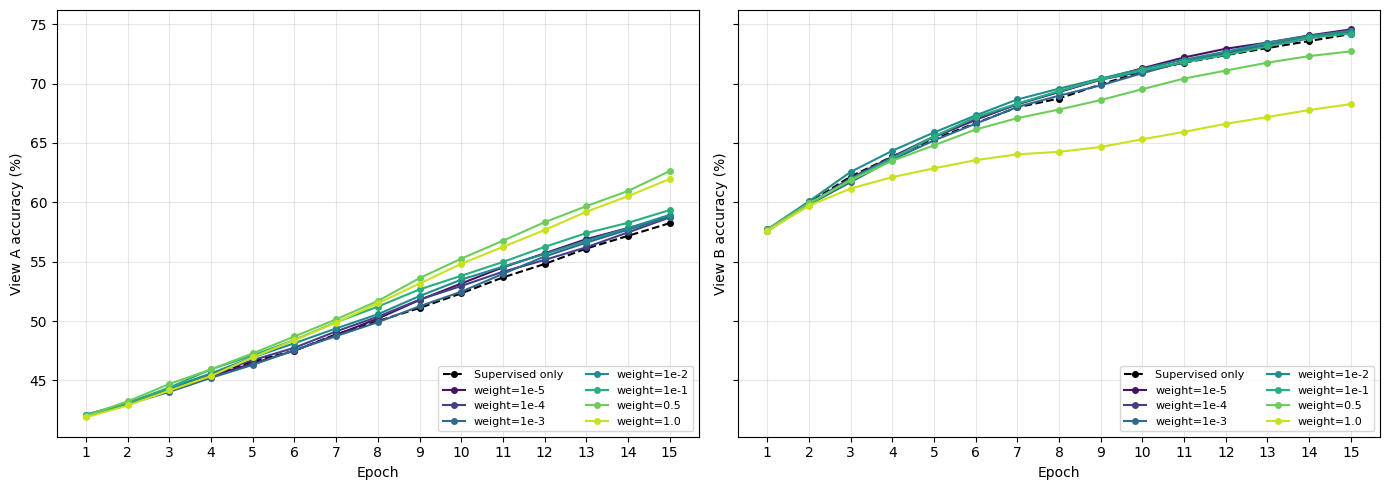

In [7]:
import matplotlib.cm as cm

epochs = np.arange(1, sup_arr_a.shape[1] + 1)
colors = cm.viridis(np.linspace(0.05, 0.92, len(WEIGHTS)))

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sup_arr, con_runs, title in [
    (ax_a, sup_arr_a, con_runs_a, "View A accuracy (%)"),
    (ax_b, sup_arr_b, con_runs_b, "View B accuracy (%)"),
]:
    ax.plot(epochs, sup_arr.mean(axis=0) * 100, color="black", marker="o",
            markersize=4, linestyle="--", label="Supervised only")
    for color, w, label in zip(colors, WEIGHTS, W_LABELS):
        ax.plot(epochs, con_runs[w].mean(axis=0) * 100, color=color, marker="o",
                markersize=4, label=f"weight={label}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.set_xticks(list(epochs))
    ax.legend(loc="lower right", fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion

The constrained model improves over the supervised baseline. With only 50 labeled
samples, each view-specific classifier cannot learn a strong decision boundary from its
own data alone. On the 5,000 unlabeled samples, the cross-view constraint acts as a
form of mutual pseudo-labeling: when model A is confident that a sample is positive,
the constraint pushes model B toward the same prediction, and vice versa. Neither model
sees the other's sensor readings. The constraint connects them purely through the
logical equivalence.

**When to use the dict pattern.** The multi-variable pattern (`X1=..., X2=...`) is the right choice when the two arguments represent different objects,  as in the Symmetry and Triplet notebooks, where `X1` and `X2` are genuinely separate items being compared. The dict pattern might be more intuitive when the arguments represent different views or modalities of the same object, and you want to keep each predicate focused on its own input without changing the logical structure of the expression.